# Temporal Fusion Transformer Model
This notebook trains and tests a Temporal Fusion Transformer model to predict delivery service time. The model uses customer history, calendar variables, planned delivery information, and other operational features to predict service time in minutes. The results from this notebook are later used in the scenario analysis, where predicted service times are used as input in the decisionsupport and optimisation models.odels.

## Import libraries and set random seed

The required libraries for data handling, modelling, and visualisation are imported. PyTorch Forecasting and Lightning are used to build and train the Temporal Fusion Transformer model. Random seeds are set to make the experiment more reproducible. This helps the training behave more consistently between runs.

In [28]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data.encoders import NaNLabelEncoder

torch.manual_seed(1)
np.random.seed(1)

## Load modelling dataset

The model dataset created in the feature engineering notebook is loaded. This dataset already contains the selected numerical features, categorical features, lag features, rolling statistics and the time index needed.

In [29]:
data = pd.read_csv("model_dataset.csv", low_memory=False, encoding="utf-8-sig")
data["Dato"] = pd.to_datetime(data["Dato"], errors="coerce")

customerColumn = "Kundenr"
dateColumn = "Dato"
timeColumn = "time_idx"
targetColumn = "Leveringstid (min)"

print("Rows:", len(data))
print("Columns:", data.columns.tolist())

Rows: 579105
Columns: ['Kundenr', 'Dato', 'time_idx', 'Leveringstid (min)', 'month', 'week', 'Planlagt leveringstid (min)', 'Antall leveranser', 'Vekt (kg)', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'dayOfWeek', 'Fylke', 'Drivstofftype']


## Prepare Numerical Values

The target variable and time index are converted to numeric format. Selected numerical input columns are also converted to numbers. This is needed because the TFT model expects numerical features in numeric format. Rows with missing key values are removed. These include customer ID, date, time index, and target value. Without these values, the sequence structure or target information would be incomplete.

In [30]:
data[targetColumn] = pd.to_numeric(data[targetColumn], errors="coerce")
data[timeColumn] = pd.to_numeric(data[timeColumn], errors="coerce")

numberColumns = [
    "month",
    "week",
    "Planlagt leveringstid (min)",
    "Antall leveranser",
    "Vekt (kg)",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7"]

for column in numberColumns:
    if column in data.columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

data = data.dropna(subset=[customerColumn, dateColumn, timeColumn, targetColumn]).copy()
data[timeColumn] = data[timeColumn].astype(int)

print("After cleaning:", len(data))

After cleaning: 579105


## Split Data into Training and Validation Sets

The dataset is split by time instead of randomly. The first 80 percent of the data is used for training, and the last 20 percent is used for validation. This is a standard approach in forecasting, since later observations should be predicted from earlier data. It also reflects how the model would be used in practice.

In [31]:
cutoffDate = data[dateColumn].quantile(0.8)

trainData = data[data[dateColumn] <= cutoffDate].copy()
valData = data[data[dateColumn] > cutoffDate].copy()

print("Cutoff date:", cutoffDate)
print("Train rows:", len(trainData))
print("Val rows:", len(valData))
print("Train range:", trainData[dateColumn].min(), "-", trainData[dateColumn].max())
print("Val range:", valData[dateColumn].min(), "-", valData[dateColumn].max())

Cutoff date: 2024-07-23 00:00:00
Train rows: 463552
Val rows: 115553
Train range: 2019-01-11 00:00:00 - 2024-07-23 00:00:00
Val range: 2024-07-24 00:00:00 - 2025-12-29 00:00:00


## Define known, unknown and categorical features

The input variables are divided into three groups. Known real features - variables that are available before prediction time, such as month, week, planned delivery time, number of deliveries and weight. Unknown real features - the target and historical servicetime features. These describe past delivery behaviour and help the model learn temporal patterns. Categorical features - nonnumerical information such as weekday, county and fuel type.

In [32]:
knownReal = ["month", "week", "Planlagt leveringstid (min)", "Antall leveranser", "Vekt (kg)"]
unknownReal = [targetColumn, "lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]
catColumns = ["dayOfWeek", "Fylke", "Drivstofftype"]

print("Known real:", knownReal)
print("Unknown real:", unknownReal)
print("Categorical:", catColumns)

Known real: ['month', 'week', 'Planlagt leveringstid (min)', 'Antall leveranser', 'Vekt (kg)']
Unknown real: ['Leveringstid (min)', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
Categorical: ['dayOfWeek', 'Fylke', 'Drivstofftype']


## Clean Categorical Values

Categorical variables are cleaned before modelling. Missing and empty values are replaced with "missing", and all values are converted to text format. This is a standard step that helps avoid encoding errors, and keeps category values consistent.

In [33]:
trainData[customerColumn] = trainData[customerColumn].fillna("missing")
valData[customerColumn] = valData[customerColumn].fillna("missing")

trainData[customerColumn] = trainData[customerColumn].astype(str).str.strip()
valData[customerColumn] = valData[customerColumn].astype(str).str.strip()

for column in catColumns:
    trainData[column] = trainData[column].fillna("missing")
    valData[column] = valData[column].fillna("missing")

    trainData[column] = trainData[column].astype(str).str.strip()
    valData[column] = valData[column].astype(str).str.strip()

trainData[customerColumn] = trainData[customerColumn].replace("", "missing")
valData[customerColumn] = valData[customerColumn].replace("", "missing")

for column in catColumns:
    trainData[column] = trainData[column].replace("", "missing")
    valData[column] = valData[column].replace("", "missing")

## Create Categorical Encoders

Categorical encoders are created for customer ID and the selected categorical features. The model cannot use text values directly, so categories are converted to numerical representations.

In [34]:
catEncoders = {
    customerColumn: NaNLabelEncoder(add_nan=True),
    "dayOfWeek": NaNLabelEncoder(add_nan=True),
    "Fylke": NaNLabelEncoder(add_nan=True),
    "Drivstofftype": NaNLabelEncoder(add_nan=True)}

print(trainData[[customerColumn] + catColumns].head())
print(valData[[customerColumn] + catColumns].head())

    Kundenr dayOfWeek     Fylke Drivstofftype
0  201966.0         1  Rogaland          GASS
1  201966.0         2  Rogaland          GASS
2  201966.0         3  Rogaland          GASS
3  201966.0         0  Rogaland          GASS
4  201966.0         2  Rogaland          GASS
      Kundenr dayOfWeek     Fylke Drivstofftype
940  201966.0         2  Rogaland          GASS
941  201966.0         3  Rogaland          GASS
942  201966.0         4  Rogaland          GASS
943  201966.0         0  Rogaland          GASS
944  201966.0         1  Rogaland          GASS


## Create TFT Training and Validation Datasets

The TimeSeriesDataSet object is used to prepare the data for the Temporal Fusion Transformer model. The first version used a simpler setup with fewer features, and a shorter encoder length. After testing the results, the setup was changed to better fit the dataset and task. The final version was based on TFT tutorial examples, but adapted to this project. The selected columns, customer grouping, target variable, and feature choices were adjusted for this delivery dataset. Observations are grouped by customer ID, so each customer is treated as a separate time series. This was chosen because the EDA showed that route IDs changed over time, while customer history was more stable and better for modelling. The encoder length was increased from 30 to 60 so the model could use more previous observations. The prediction length is set to 1 because the goal is to predict the next service time. The validation dataset uses the same structure as the training dataset. Dataloaders are then created for model training and validation.

In [35]:
maxEncoderLength = 60
maxPredictionLength = 1

trainSet = TimeSeriesDataSet(
    trainData,
    time_idx=timeColumn,
    target=targetColumn,
    group_ids=[customerColumn],
    max_encoder_length=maxEncoderLength,
    max_prediction_length=maxPredictionLength,
    time_varying_known_reals=knownReal,
    time_varying_known_categoricals=catColumns,
    time_varying_unknown_reals=unknownReal,
    categorical_encoders=catEncoders)

valSet = TimeSeriesDataSet.from_dataset(
    trainSet,
    valData,
    stop_randomization=True)

batchSize = 128

trainLoader = trainSet.to_dataloader(train=True, batch_size=batchSize, num_workers=0)
valLoader = valSet.to_dataloader(train=False, batch_size=batchSize, num_workers=0)

print("Train samples:", len(trainSet))
print("Val samples:", len(valSet))

Train samples: 373338
Val samples: 63552


## Define the Temporal Fusion Transformer Model

After preparing the training and validation datasets, the TFT model is defined. The first version used a simpler setup with lower model capacity, including hidden_size 16, hidden_continuous_size 8, attention_head_size 1, and encoder length 30. After testing the early results, the parameters were changed to see if performance could improve. This new tuned model is created from the training dataset using the from_dataset() function. The learning rate was changed to 0.001 for more stable training. Hidden size was increased from 16 to 32, hidden_continuous_size from 8 to 16, and attention_head_size from 1 to 4. Lstm_layers was set to 2, while dropout was kept at 0.1. The model uses attention and recurrent layers to learn historical patterns.

In [36]:
tft = TemporalFusionTransformer.from_dataset(
    trainSet,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=4,
    hidden_continuous_size=16,
    lstm_layers=2,
    dropout=0.1,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4)

print("Model ready")

Model ready


## Train the Model

The model is trained using the training and validation dataloaders. The first TFT version used max_epochs 8, and early stopping patience 3. After testing the first results, the final tuned model used max_epochs 20 and patience 5.This gave the model more time to learn before training stopped. Validation loss was used to select the best model. A checkpoint is saved for the best version, which is later used for prediction and evaluation. The Trainer object controls the training process, and fit() starts the model training.

In [ ]:
earlyStop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min")

checkpoint = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="tft-best")

trainer = Trainer(
    max_epochs=20,
    accelerator="auto",
    enable_checkpointing=True,
    callbacks=[earlyStop, checkpoint],
    logger=False)

trainer.fit(tft, trainLoader, valLoader)

print("Best checkpoint:", checkpoint.best_model_path)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    108 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    320 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 21.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 10.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 16.9 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 16.9 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 394                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

## Load Saved Model Checkpoint

The best saved TFT checkpoint is loaded. Now the trained model can be reused for prediction and evaluation.

In [38]:
checkpointPath = "checkpoints/tft-best.ckpt"
bestModel = TemporalFusionTransformer.load_from_checkpoint(checkpointPath)

print("Loaded saved model")

Loaded saved model


## Generate validation predictions

The saved TFT model is loaded from the checkpoint file. Predictions are generated for the validation dataset and saved to predictions.csv. These predictions are later used in the scenario analysis.

In [39]:
checkpointPath = "checkpoints/tft-best.ckpt"
bestModel = TemporalFusionTransformer.load_from_checkpoint(checkpointPath)

predictions = bestModel.predict(valLoader, return_y=True, return_index=True)

predArray = predictions.output.detach().cpu().numpy()
midCol = predArray.shape[1] // 2
predTime = predArray[:, midCol]
trueTime = predictions.y[0].detach().cpu().numpy().reshape(-1)

predData = predictions.index.reset_index(drop=True).copy()
predData["predikert_leveringstid"] = predTime
predData["faktisk_leveringstid"] = trueTime

predData = predData.merge(
    valData[[customerColumn, timeColumn, dateColumn]],
    on=[customerColumn, timeColumn],
    how="left"
)

predData["dato"] = pd.to_datetime(predData[dateColumn], errors="coerce").dt.date

print(predData.shape)
predData.to_csv("predictions.csv", index=False, encoding="utf-8-sig")

print("Saved predictions.csv")
print(predData.head())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


(63552, 6)
Saved predictions.csv
   time_idx    Kundenr  predikert_leveringstid  faktisk_leveringstid  \
0        60  1000421.0               14.204079             13.383333   
1        61  1000421.0               14.477991             10.166667   
2        62  1000421.0               27.888367             35.650002   
3        63  1000421.0               20.023878             37.633335   
4        64  1000421.0               29.986776             48.166668   

        Dato        dato  
0 2025-08-08  2025-08-08  
1 2025-08-11  2025-08-11  
2 2025-08-12  2025-08-12  
3 2025-08-13  2025-08-13  
4 2025-08-14  2025-08-14  


## Evaluate Prediction Accuracy

After the predictions have been created, the next step is to evaluate how close they are to the actual service times. The predicted values are compared with the real values, and error metrics such as MAE, RMSE, and MAPE are calculated. This gives an overview of model performance before the predictions are used later in the scenario analysis. MAE is especially useful here, since it shows the average error directly in minutes. MAPE is only included for comparison, but is not reliable when actual values are low.

In [40]:
errors = predData["predikert_leveringstid"] - predData["faktisk_leveringstid"]
absErrors = errors.abs()

mae = absErrors.mean()
rmse = np.sqrt((errors ** 2).mean())
mape = (absErrors / predData["faktisk_leveringstid"].replace(0, np.nan)).mean() * 100

print("Model evaluation:")
print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"MAPE: {mape:.2f}%")
print(f"Validation predictions: {len(predData)}")

Model evaluation:
MAE: 5.66 minutes
RMSE: 11.49 minutes
MAPE: 101.84%
Validation predictions: 63552


## Create Shock Dataset

After evaluating the base model predictions, the next step is to create a shock dataset for scenario testing. A copy of the validation dataset is used, where selected variables are increased to simulate higher workload. In this case, weight is increased by 80 percent. This is done to test how predicted service times may change when deliveries become heavier. The same dataset structure is reused so the shock data can be used in the trained TFT model.

In [42]:
shockData = valData.copy()

shockData["Vekt (kg)"] = (pd.to_numeric(shockData["Vekt (kg)"], errors="coerce").fillna(0) * 1.8)
shockSet = TimeSeriesDataSet.from_dataset(trainSet, shockData, stop_randomization=True)
shockLoader = shockSet.to_dataloader(train=False, batch_size=batchSize, num_workers=0)

## Predict Service Time Under Shock Scenario

After the shock dataset has been created, the next step is to generate new predictions using the trained model. This is done to estimate service times under higher workload conditions. The model predicts service time for the modified dataset, and the middle quantile is used as the main predicted value. The results are then saved to predictions_shock.csv. 

In [43]:
shockPredictions = bestModel.predict(shockLoader, return_index=True)

shockArray = shockPredictions.output.detach().cpu().numpy()
midCol = shockArray.shape[1] // 2
shockTime = shockArray[:, midCol]

shockDataFrame = shockPredictions.index.reset_index(drop=True).copy()
shockDataFrame["predikert_leveringstid_shock"] = shockTime

shockDataFrame = shockDataFrame.merge(
    valData[[customerColumn, timeColumn, dateColumn]],
    on=[customerColumn, timeColumn],
    how="left")

shockDataFrame["dato"] = pd.to_datetime(shockDataFrame[dateColumn], errors="coerce").dt.date
shockDataFrame.to_csv("predictions_shock.csv", index=False, encoding="utf-8-sig")

print("Saved predictions_shock.csv")
print(shockDataFrame.head())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Saved predictions_shock.csv
   time_idx    Kundenr  predikert_leveringstid_shock       Dato        dato
0        60  1000421.0                     15.983128 2025-08-08  2025-08-08
1        61  1000421.0                     14.011360 2025-08-11  2025-08-11
2        62  1000421.0                     32.411587 2025-08-12  2025-08-12
3        63  1000421.0                     24.008308 2025-08-13  2025-08-13
4        64  1000421.0                     34.516308 2025-08-14  2025-08-14


## Compare normal and shock predictions

After predictions have been created for both the normal and shock datasets, the next step is to compare the results. This is done to check if the model reacts in a realistic way when workload changes. The normal predictions are compared with the shock predictions. If service times become higher, it suggests that the model captures the effect of heavier deliveries.

In [44]:
comparison = predData.copy()

comparison["shockTime"] = shockTime
comparison["difference"] = comparison["shockTime"] - comparison["predikert_leveringstid"]

print("Average change:", comparison["difference"].mean())
print("Median change:", comparison["difference"].median())

Average change: 0.95507854
Median change: 0.3410027


## Prepare actual and predicted values for plotting

After the prediction results have been evaluated, the next step is to prepare the actual and predicted service times for the following plots. The values are separated into two variables to make comparison easier.

In [45]:
yTrue = predData["faktisk_leveringstid"]
yPred = predData["predikert_leveringstid"]

## Plot predicted versus actual service time

The next step is to compare predicted and actual service times in a scatter plot. This gives a quick visual check of model performance. If predictions were perfect, the points would lie close to the diagonal line. Points closer to the line indicate better predictions.

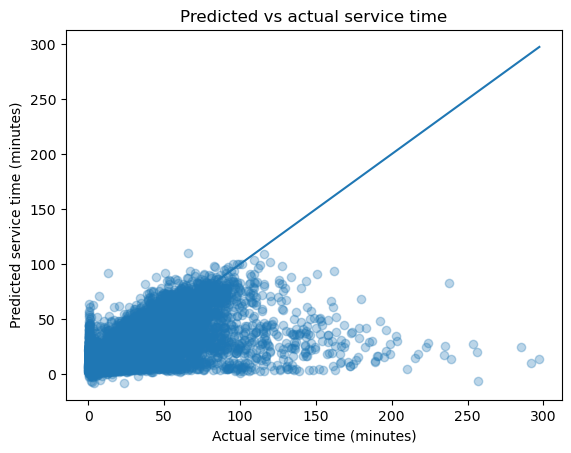

In [46]:
plt.figure()
plt.scatter(yTrue, yPred, alpha=0.3)
plt.plot([yTrue.min(), yTrue.max()], [yTrue.min(), yTrue.max()])
plt.xlabel("Actual service time (minutes)")
plt.ylabel("Predicted service time (minutes)")
plt.title("Predicted vs actual service time")
plt.show()

## Zoomed predicted versus actual plot

The same plot is shown again with limits from 0 to 120 minutes to make the visualisation more detailed and easier to inspect.

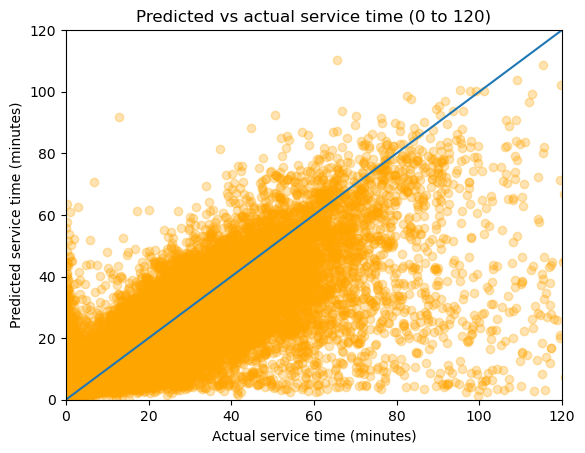

In [47]:
plt.figure()
plt.scatter(yTrue, yPred, alpha=0.3, color = "orange")
plt.plot([yTrue.min(), yTrue.max()], [yTrue.min(), yTrue.max()])
plt.xlabel("Actual service time (minutes)")
plt.ylabel("Predicted service time (minutes)")
plt.title("Predicted vs actual service time (0 to 120)")
plt.xlim(0, 120)
plt.ylim(0, 120)
plt.show()

## Distribution of prediction errors
This step is to examine the prediction errors using the values created earlier. Prediction error is calculated as predicted service time minus actual service time. The histogram is used to see whether most errors are close to zero, and whether the model tends to overestimate or underestimate service time.

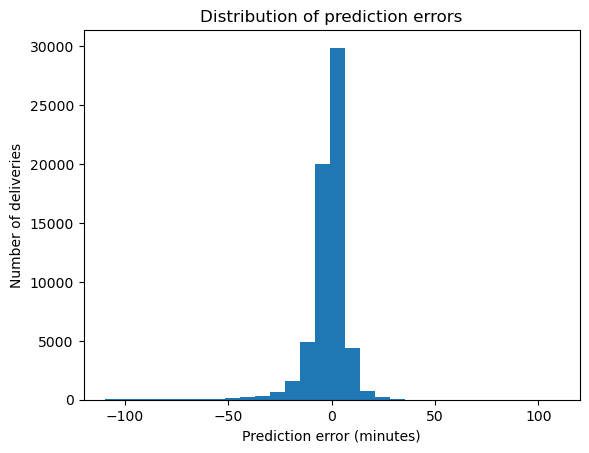

In [48]:
errors = yPred - yTrue
plt.figure()
plt.hist(errors, bins=50)
plt.xlabel("Prediction error (minutes)")
plt.ylabel("Number of deliveries")
plt.title("Distribution of prediction errors")
plt.xlim(-120, 120)
plt.show()

## Analyse of underestimation and overestimation

This step evaluates whether the model tends to predict values that are too low or too high. 
Underestimation means the predicted delivery time is shorter than the actual time, while 
overestimation means the prediction is longer than the actual time. This helps identify 
systematic bias in the model predictions.

In [49]:
errors = predData["predikert_leveringstid"] - predData["faktisk_leveringstid"]

under = (errors < 0).mean() * 100
over = (errors > 0).mean() * 100

print(f"Underestimation: {under:.1f}%")
print(f"Overestimation: {over:.1f}%")

Underestimation: 50.6%
Overestimation: 49.4%


## Predictions within +-1 and +-5 minutes

These metrics measure how often the model predicts delivery times close to the actual values. 
A difference of +-1 minute represents high precision and shows how often the model makes near-perfect predictions. 

The +- 5 minute metric reflects practical accuracy. In real logistics operations, small deviations are acceptable, 
so this measure shows how useful the model is for real-world planning.

In [51]:
almost_exact = (errors.abs() <= 1).mean() * 100
print(f"Within +- minute: {almost_exact:.1f}%")

within_5 = (errors.abs() <= 5).mean() * 100
print(f"Within +- minutes: {within_5:.1f}%")

Within +- minute: 18.3%
Within +- minutes: 66.2%
